# Phase 1: Player Valuation Model

**Goal:** Build a systematic answer to one question — *who is undervalued relative to their contract?* That answer drives every downstream decision: who to trade for, who to sign, who to build around.

This notebook constructs three interlocking rankings:
1. **On-court value** — how good is this player, measured by a weighted blend of advanced metrics
2. **Surplus value** — how much value does a player deliver *relative to what they cost*
3. **Luka complement score** — how well does a player's style fit alongside a ball-dominant creator

The end product is a combined target list: players who score well on all three. These are the Lakers' offseason targets.

---

## The Core Idea

The 2023-24 Dallas Mavericks are the case study for this project. A good team became a Finals team because of two mid-season acquisitions: PJ Washington and Daniel Gafford. Neither was a star. Both were undervalued relative to their contracts and stylistically ideal for Luka's game.

This model tries to build a framework that could have identified those moves *before* they happened — and to apply the same logic to the Lakers' situation heading into 2026-27.

In [3]:
import sys
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.width', 140)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
LAKERS_PURPLE = '#552583'
LAKERS_GOLD   = '#FDB927'

print('Environment ready.')


Environment ready.


## A) Build the Full Valued Dataset

We merge four nba_api sources, Basketball Reference advanced stats, and salary data into one player-level DataFrame, then run the valuation and complement models on top.

In [4]:
from src.data.merge import build_player_dataset, completeness_summary
from src.features.player_value import compute_player_value, surplus_leaderboard, overpaid_leaderboard, fa_leaderboard, ON_COURT_WEIGHTS
from src.features.luka_complement import (
    compute_luka_complement, cluster_profile, get_complement_cluster_members,
    EXPANDED_VALIDATION, CLUSTER_FEATURES
)
from src.utils.constants import SALARY_CAP_2026_27, SALARY_CAP, FIRST_APRON_2026_27, SECOND_APRON_2026_27

SEASON = '2025-26'

# Build the base merged dataset (uses cached parquet -- no live API calls)
raw = build_player_dataset(SEASON)
print(f'Raw dataset: {raw.shape[0]} players, {raw.shape[1]} columns')

Raw dataset: 582 players, 185 columns


In [5]:
# Source completeness -- what % of players have data from each source?
print('Data completeness by source:')
completeness_summary(raw)

Data completeness by source:


,source,sentinel_col,coverage_pct,n_players,n_total
0,nba_api_base,PTS,100.000,582,582
1,nba_api_advanced,NET_RATING,100.000,582,582
2,nba_api_defense,PCT_PLUSMINUS,99.800,581,582
3,bbref_advanced,BPM,99.300,578,582
4,bbref_ws,WS,99.300,578,582
5,bbref_per,PER,99.300,578,582
6,bbref_vorp,VORP,99.300,578,582
7,nba_api_shooting,CS_CATCH_SHOOT_FG3_PCT,93.600,545,582
8,salary_years,YEARS_REMAINING,80.600,469,582
9,salary_current,SALARY,80.400,468,582


In [6]:
# Apply valuation model with durability scoring enabled (uses cached nba_api data, no live calls)
val = compute_player_value(raw, current_season=SEASON, add_durability=True)

# Apply Luka complement scoring
df = compute_luka_complement(val)

print(f'Valued dataset: {df.shape[0]} players, {df.shape[1]} columns')
print(f'  Qualifying players (GP>=20, MIN>=15): {df["ON_COURT_VALUE"].notna().sum()}')
print(f'  Non-FA players (have 2026-27 salary): {(~df["IS_FREE_AGENT"]).sum()}')
print(f'  Free agents (no 2026-27 salary):       {df["IS_FREE_AGENT"].sum()}')
print(f'  Players with surplus value:            {df["SURPLUS_VALUE"].notna().sum()}')
print(f'  Players with complement distance:      {df["COMPLEMENT_DISTANCE"].notna().sum()}')

# Sanity check: Austin Reaves should show as free agent (PO decline override)
ar = df[df['PLAYER_NAME'].str.contains('Reaves', na=False)]
if not ar.empty:
    r = ar.iloc[0]
    print(f'\nAustin Reaves: IS_FREE_AGENT={r["IS_FREE_AGENT"]}, SALARY_FORWARD={r["SALARY_FORWARD"]}')
    print('  (Expected: IS_FREE_AGENT=True -- PO decline override applied)')


Valued dataset: 582 players, 221 columns
  Qualifying players (GP>=20, MIN>=15): 350
  Non-FA players (have 2026-27 salary): 325
  Free agents (no 2026-27 salary):       257
  Players with surplus value:            263
  Players with complement distance:      348

Austin Reaves: IS_FREE_AGENT=True, SALARY_FORWARD=nan
  (Expected: IS_FREE_AGENT=True -- PO decline override applied)


## B) On-Court Value Distribution

### What is ON_COURT_VALUE?

It's a weighted blend of z-scored advanced metrics. Each metric is standardized within the qualifying population (players with >= 20 GP and >= 15 MIN/game), so a score of 0 means exactly league average and +1 means one standard deviation above average.

**Weights:**
| Metric | Weight | Rationale |
|--------|--------|-----------|
| BPM | 35% | Best single metric for individual impact, relatively team-context-independent |
| VORP | 25% | Cumulative value — implicitly rewards durability (more games = more VORP) |
| WS/48 | 15% | Rate-based counterweight to VORP's volume bias |
| NET_RATING | 15% | Team-level on/off impact; captures team defense BPM can miss |
| TS% | 10% | Scoring efficiency; lower weight because it ignores non-scoring value |

These are starting hypotheses, not ground truth. The weights are constants in `src/features/player_value.py` — easily tunable.

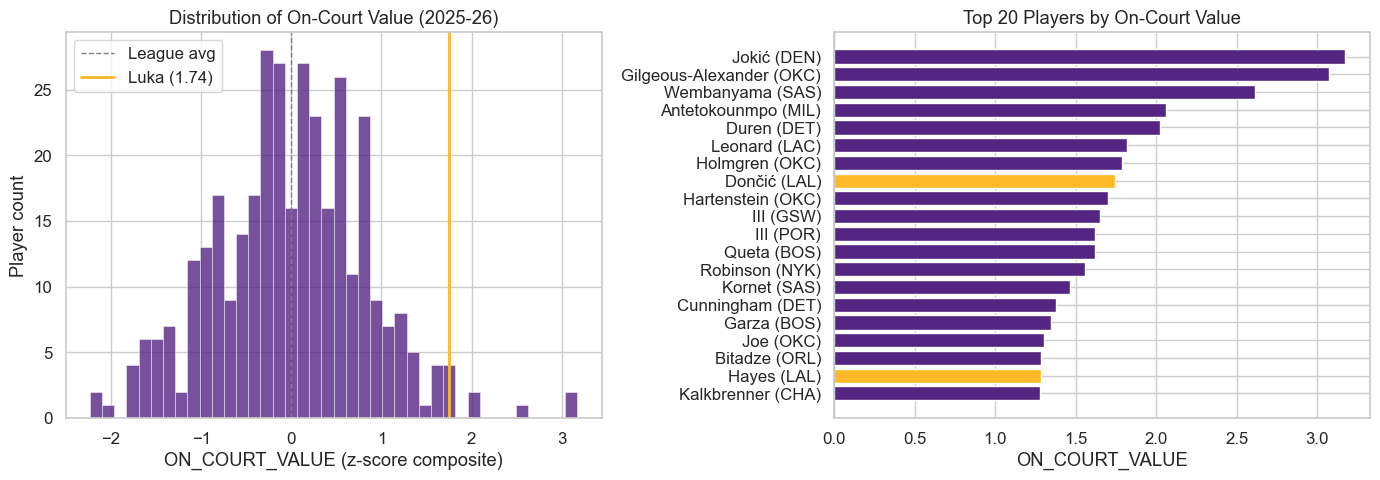

In [7]:
qual = df[df['ON_COURT_VALUE'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
ax = axes[0]
ax.hist(qual['ON_COURT_VALUE'], bins=40, color=LAKERS_PURPLE, alpha=0.8, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='gray', linestyle='--', linewidth=1, label='League avg')
ax.set_xlabel('ON_COURT_VALUE (z-score composite)')
ax.set_ylabel('Player count')
ax.set_title('Distribution of On-Court Value (2025-26)')
ax.legend()

# Luka highlighted
luka_val = df.loc[df['PLAYER_ID'] == 1629029, 'ON_COURT_VALUE'].values
if len(luka_val):
    ax.axvline(luka_val[0], color=LAKERS_GOLD, linestyle='-', linewidth=2, label=f'Luka ({luka_val[0]:.2f})')
    ax.legend()

# Top 20 bar chart
ax2 = axes[1]
top20 = qual.nlargest(20, 'ON_COURT_VALUE')[['PLAYER_NAME', 'ON_COURT_VALUE', 'TEAM_ABBREVIATION']].copy()
top20['label'] = top20['PLAYER_NAME'].str.split().str[-1] + ' (' + top20['TEAM_ABBREVIATION'] + ')'
colors = [LAKERS_GOLD if t == 'LAL' else LAKERS_PURPLE for t in top20['TEAM_ABBREVIATION']]
ax2.barh(top20['label'][::-1], top20['ON_COURT_VALUE'][::-1], color=colors[::-1])
ax2.set_xlabel('ON_COURT_VALUE')
ax2.set_title('Top 20 Players by On-Court Value')
ax2.axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

In [8]:
# Smell test: does this ranking make basketball sense?
top25 = qual.nlargest(25, 'ON_COURT_VALUE')[[
    'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE',
    'ON_COURT_VALUE', 'Z_BPM', 'Z_VORP', 'Z_WS_48', 'Z_NET_RATING', 'Z_TS_PCT',
    'IS_FREE_AGENT', 'SURPLUS_VALUE'
]]
print('Top 25 players by ON_COURT_VALUE:')
top25

Top 25 players by ON_COURT_VALUE:


,PLAYER_NAME,TEAM_ABBREVIATION,AGE,ON_COURT_VALUE,Z_BPM,Z_VORP,Z_WS_48,Z_NET_RATING,Z_TS_PCT,IS_FREE_AGENT,SURPLUS_VALUE
429,Nikola Jokić,DEN,31.000,3.172,4.853,5.989,3.656,1.585,1.729,False,-1.097
501,Shai Gilgeous-Alexander,OKC,27.000,3.076,4.008,4.981,3.773,2.368,1.633,False,0.123
559,Victor Wembanyama,SAS,22.000,2.612,3.670,3.686,2.670,2.468,0.884,False,1.526
186,Giannis Antetokounmpo,MIL,31.000,2.058,3.265,1.527,2.235,0.674,1.499,False,-1.717
232,Jalen Duren,DET,22.000,2.022,1.745,1.887,2.820,1.728,2.075,True,NaN
320,Kawhi Leonard,LAC,34.000,1.816,2.758,3.182,1.917,1.115,0.941,False,-1.289
88,Chet Holmgren,OKC,24.000,1.788,1.475,1.599,2.034,2.340,1.403,False,-0.689
372,Luka Dončić,LAL,27.000,1.745,3.197,4.118,1.700,0.589,0.691,False,-1.297
208,Isaiah Hartenstein,OKC,28.000,1.699,1.475,0.664,2.101,2.268,0.980,False,0.170
275,Jimmy Butler III,GSW,36.000,1.649,1.914,1.023,2.268,1.087,1.268,False,-1.846


**Smell test:** Jokic, SGA, and Wembanyama at the top is exactly right. These are the consensus top-3 players in the league by most advanced metrics. Luka being in the mix sense given his scoring efficiency, though his defensive BPM drags on the score. Any reasonable model should put these four in the top 5-6.

One thing to watch: VORP accumulates over games played, so injured players may be underrated here. That's intentional — *availability is a skill* and the durability adjustment (ADJUSTED_VALUE) will apply a discount to high-risk players.

## C) Surplus Value: Who Is Undervalued (and Overpaid)?

**Surplus value** = on-court value minus contract cost. Both are expressed as z-scores, so the comparison is apples-to-apples.

A player with SURPLUS_VALUE > 0 produces more value than their contract implies. That's the signal we're hunting. The bigger the surplus, the better the trade or signing target.

Key caveat: we're using **2026-27 salary** as the cost (the upcoming season), not the current one. This is the correct framing — we're building for 2026-27, so we care about what these players will cost the Lakers next year.

In [9]:
# Top 30 most undervalued (high on-court value relative to contract cost)
print('=== TOP 30 MOST UNDERVALUED (Non-FA) ===')
undervalued = surplus_leaderboard(df, n=30)
display_cols = [
    'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE',
    'ON_COURT_VALUE', 'SALARY_FORWARD', 'CONTRACT_VALUE', 'SURPLUS_VALUE', 'SURPLUS_RANK'
]
avail = [c for c in display_cols if c in undervalued.columns]
undervalued_fmt = undervalued[avail].copy()
undervalued_fmt['SALARY_FORWARD'] = (undervalued_fmt['SALARY_FORWARD'] / 1e6).map('${:.1f}M'.format)
undervalued_fmt['CONTRACT_VALUE'] = (undervalued_fmt['CONTRACT_VALUE'] * 100).map('{:.1f}%'.format)
undervalued_fmt

=== TOP 30 MOST UNDERVALUED (Non-FA) ===


,PLAYER_NAME,TEAM_ABBREVIATION,AGE,ON_COURT_VALUE,SALARY_FORWARD,CONTRACT_VALUE,SURPLUS_VALUE,SURPLUS_RANK
0,Neemias Queta,BOS,26.000,1.617,$2.7M,1.7%,1.931,1.000
1,Luka Garza,BOS,27.000,1.344,$2.8M,1.8%,1.760,2.000
2,Ryan Kalkbrenner,CHA,24.000,1.276,$2.4M,1.5%,1.747,3.000
3,Moussa Diabaté,CHA,24.000,1.190,$2.5M,1.6%,1.692,4.000
4,Ajay Mitchell,OKC,23.000,1.027,$2.9M,1.8%,1.568,5.000
5,Sandro Mamukelashvili,TOR,27.000,1.010,$2.8M,1.8%,1.562,6.000
6,Victor Wembanyama,SAS,22.000,2.612,$16.9M,10.7%,1.526,7.000
7,Julian Champagnie,SAS,24.000,0.866,$3.0M,1.9%,1.462,8.000
8,Josh Minott,BKN,23.000,0.743,$2.6M,1.6%,1.419,9.000
9,Goga Bitadze,ORL,26.000,1.284,$7.6M,4.8%,1.387,10.000


In [10]:
# Top 30 most overpaid (low or negative on-court value relative to contract)
print('=== TOP 30 MOST OVERPAID (Non-FA) ===')
overpaid = overpaid_leaderboard(df, n=30)
avail = [c for c in display_cols if c in overpaid.columns]
overpaid_fmt = overpaid[avail].copy()
overpaid_fmt['SALARY_FORWARD'] = (overpaid_fmt['SALARY_FORWARD'] / 1e6).map('${:.1f}M'.format)
overpaid_fmt['CONTRACT_VALUE'] = (overpaid_fmt['CONTRACT_VALUE'] * 100).map('{:.1f}%'.format)
overpaid_fmt

=== TOP 30 MOST OVERPAID (Non-FA) ===


,PLAYER_NAME,TEAM_ABBREVIATION,AGE,ON_COURT_VALUE,SALARY_FORWARD,CONTRACT_VALUE,SURPLUS_VALUE
0,Anthony Davis,WAS,33.000,0.059,$58.5M,37.2%,-2.903
1,Zach LaVine,SAC,31.000,-0.619,$49.0M,31.2%,-2.639
2,Stephen Curry,GSW,38.000,1.155,$62.6M,39.9%,-2.542
3,Devin Booker,PHX,29.000,0.609,$57.1M,36.4%,-2.480
4,Jaren Jackson Jr.,UTA,26.000,-0.294,$49.0M,31.2%,-2.449
5,Pascal Siakam,IND,32.000,-0.272,$48.9M,31.2%,-2.431
6,Paul George,PHI,36.000,0.358,$54.1M,34.5%,-2.422
7,Jaylen Brown,BOS,29.000,0.752,$57.1M,36.4%,-2.395
8,Ja Morant,MEM,26.000,-0.775,$42.2M,26.9%,-2.255
9,Joel Embiid,PHI,32.000,1.133,$58.1M,37.0%,-2.241


**Does this make basketball sense?**

The undervalued list should be heavy on young players on rookie-scale deals and role players who dramatically outperform their salaries. Players on the overpaid list are often veterans whose production has declined but who signed large deals during peak seasons.

This is the core inefficiency signal. In an efficient market these opportunities wouldn't exist — the fact that they do is the premise of this whole project.

From a personal perspective, Overvalued list has some shocking names: Jalen Brown, Deving Booker, Cade Cunngingham, Donovan Mitchell. Mitchell, Cade, and Brown are All NBA award winners this season so overvalued does not make sense here. 

In [11]:
# Scatter: contract value vs on-court value -- Plotly for interactive tooltips
# Note: Plotly charts are interactive in Jupyter but won't render in static GitHub preview.
# Run fig.write_html('../docs/scatter_value_vs_cost.html') to save a standalone interactive version.

plot_df = df[df['SURPLUS_VALUE'].notna()].copy()
plot_df['_is_laker'] = (plot_df['TEAM_ABBREVIATION'] == 'LAL').map({True: 'Lakers', False: 'Other'})

fig = px.scatter(
    plot_df,
    x='CONTRACT_VALUE_Z',
    y='ON_COURT_VALUE',
    color='_is_laker',
    color_discrete_map={'Lakers': LAKERS_GOLD, 'Other': 'steelblue'},
    hover_name='PLAYER_NAME',
    hover_data={
        'TEAM_ABBREVIATION': True,
        'AGE': True,
        'SURPLUS_VALUE': ':.3f',
        'SALARY_FORWARD': ':$,.0f',
        'CONTRACT_VALUE_Z': ':.3f',
        '_is_laker': False,
    },
    title='On-Court Value vs. Contract Cost (2026-27 salaries)<br><sup>Points above the diagonal = undervalued</sup>',
    labels={
        'CONTRACT_VALUE_Z': 'Contract Cost (z-score of salary % of cap)',
        'ON_COURT_VALUE': 'On-Court Value (weighted z-score)',
    },
    opacity=0.7,
)

# Fair-value diagonal (surplus = 0 line)
lim = max(abs(plot_df['CONTRACT_VALUE_Z'].max()), abs(plot_df['ON_COURT_VALUE'].max())) + 0.5
fig.add_shape(type='line', x0=-lim, y0=-lim, x1=lim, y1=lim,
              line=dict(color='black', width=1, dash='dash'))

fig.update_layout(width=900, height=650, legend_title='Team')
fig.show()

# Regression fit summary
print('Surplus methodology: regression-based (EXPECTED_SALARY - ACTUAL_SALARY)')
print(f'  Regression trained on {df["EXPECTED_SALARY"].notna().sum()} non-FA qualifying players')
print('  Positive SURPLUS_VALUE_DOLLARS = underpaid vs. market rate')

# --- Matplotlib fallback (static, for export / GitHub preview) ---
# fig2, ax = plt.subplots(figsize=(12, 8))
# is_lal = plot_df['TEAM_ABBREVIATION'] == 'LAL'
# ax.scatter(plot_df.loc[~is_lal,'CONTRACT_VALUE_Z'], plot_df.loc[~is_lal,'ON_COURT_VALUE'],
#            alpha=0.4, s=20, color='steelblue', label='Other teams')
# ax.scatter(plot_df.loc[is_lal,'CONTRACT_VALUE_Z'], plot_df.loc[is_lal,'ON_COURT_VALUE'],
#            alpha=0.9, s=60, color=LAKERS_GOLD, edgecolors=LAKERS_PURPLE, linewidths=0.8,
#            zorder=5, label='Lakers')
# plt.tight_layout(); plt.show()


Surplus methodology: regression-based (EXPECTED_SALARY - ACTUAL_SALARY)
  Regression trained on 263 non-FA qualifying players
  Positive SURPLUS_VALUE_DOLLARS = underpaid vs. market rate


In [30]:
# Free Agent Value Board
print('=== FREE AGENT VALUE BOARD ===')
print('These players have no 2026-27 contract -- they can be signed without trading assets.')
print('Ranked by ON_COURT_VALUE (their production, unconstrained by cost).')
print()

fa_cols = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE', 'FA_VALUE', 'FA_VALUE_RANK',
           'COMPLEMENT_DISTANCE', 'ROLL_GRAVITY_SCORE']
fa_avail = [c for c in fa_cols if c in df.columns]
fa_board = df[df['IS_FREE_AGENT'] & df['FA_VALUE'].notna()].nlargest(30, 'FA_VALUE')[fa_avail]
fa_board

=== FREE AGENT VALUE BOARD ===
These players have no 2026-27 contract -- they can be signed without trading assets.
Ranked by ON_COURT_VALUE (their production, unconstrained by cost).



,PLAYER_NAME,TEAM_ABBREVIATION,AGE,FA_VALUE,FA_VALUE_RANK,COMPLEMENT_DISTANCE,ROLL_GRAVITY_SCORE
232,Jalen Duren,DET,22.000,2.022,1.000,5.611,3.816
478,Robert Williams III,POR,28.000,1.617,2.000,6.048,5.031
405,Mitchell Robinson,NYK,28.000,1.556,3.000,7.693,7.850
258,Jaxson Hayes,LAL,26.000,1.283,4.000,6.853,3.441
391,Matisse Thybulle,POR,29.000,1.045,5.000,8.094,-0.137
386,Mark Williams,PHX,24.000,0.975,6.000,7.108,5.036
37,Austin Reaves,LAL,27.000,0.961,7.000,0.921,-2.027
257,Javonte Green,DET,32.000,0.850,8.000,3.824,0.869
364,LeBron James,LAL,41.000,0.704,9.000,1.362,-1.743
525,Tobias Harris,DET,33.000,0.689,10.000,1.776,0.067


## D) Lakers 2026-27 Cap Picture

Before we can evaluate trade targets, we need to know what the Lakers are working with. The offseason strategy depends entirely on the cap situation: are the Lakers a trade team, a free agency team, or both?

Projected 2026-27 cap: **$157M** (modest growth from the $154.6M 2025-26 cap; official figures typically announced in late June/early July).

In [13]:
lakers = df[df['TEAM_ABBREVIATION'] == 'LAL'].copy()

# Players under contract for 26-27
lal_contracted = lakers[~lakers['IS_FREE_AGENT']].sort_values('2026-27', ascending=False)
lal_free_agents = lakers[lakers['IS_FREE_AGENT']].sort_values('SALARY', ascending=False)

print(f'=== LAKERS 2026-27 COMMITTED SALARIES ===')
print(f'(Projected cap: ${SALARY_CAP_2026_27/1e6:.0f}M | First apron: ${FIRST_APRON_2026_27/1e6:.0f}M | Second apron: ${SECOND_APRON_2026_27/1e6:.0f}M)')
print()
committed_cols = ['PLAYER_NAME', 'AGE', '2026-27', 'YEARS_REMAINING', 'ON_COURT_VALUE', 'SURPLUS_VALUE']
avail_c = [c for c in committed_cols if c in lal_contracted.columns]
display_committed = lal_contracted[avail_c].copy()
display_committed['2026-27'] = (display_committed['2026-27'] / 1e6).map('${:.2f}M'.format)
print(display_committed.to_string(index=False))

total_committed = lakers[~lakers['IS_FREE_AGENT']]['2026-27'].sum()
print()
print(f'Total committed payroll (26-27): ${total_committed/1e6:.1f}M')
print(f'Distance from first apron:        ${(FIRST_APRON_2026_27 - total_committed)/1e6:.1f}M')
print(f'Distance from second apron:       ${(SECOND_APRON_2026_27 - total_committed)/1e6:.1f}M')

=== LAKERS 2026-27 COMMITTED SALARIES ===
(Projected cap: $157M | First apron: $199M | Second apron: $212M)

      PLAYER_NAME    AGE 2026-27  YEARS_REMAINING  ON_COURT_VALUE  SURPLUS_VALUE
      Luka Dončić 27.000 $49.80M            3.000           1.745         -1.297
Jarred Vanderbilt 27.000 $12.43M            2.000          -0.339          0.087
    Deandre Ayton 27.000  $8.10M            1.000           0.480          0.876
     Jake LaRavia 24.000  $6.00M            1.000          -0.173          0.636
     Marcus Smart 32.000  $5.39M            1.000          -0.274          0.619
    Dalton Knecht 25.000  $4.20M            2.000             NaN            NaN
     Bronny James 21.000  $2.30M            2.000             NaN            NaN
      Adou Thiero 22.000  $2.15M            2.000             NaN            NaN

Total committed payroll (26-27): $90.4M
Distance from first apron:        $108.2M
Distance from second apron:       $121.5M


In [14]:
print('=== LAKERS EXPIRING / FREE AGENTS AFTER 2025-26 ===')
print('These players come off the books -- either retained or replaced.')
print()
fa_cols_lal = ['PLAYER_NAME', 'AGE', 'SALARY', 'ON_COURT_VALUE', 'FA_VALUE']
avail_fa = [c for c in fa_cols_lal if c in lal_free_agents.columns]
display_fa = lal_free_agents[avail_fa].copy()
display_fa['SALARY'] = (display_fa['SALARY'] / 1e6).map('${:.2f}M'.format)
print(display_fa.to_string(index=False))
print()
print(f'Total expiring salary (would clear from books): ${lal_free_agents["SALARY"].sum()/1e6:.1f}M')

=== LAKERS EXPIRING / FREE AGENTS AFTER 2025-26 ===
These players come off the books -- either retained or replaced.

   PLAYER_NAME    AGE  SALARY  ON_COURT_VALUE  FA_VALUE
  LeBron James 41.000 $52.63M           0.704     0.704
 Rui Hachimura 28.000 $18.26M          -0.062    -0.062
 Austin Reaves 27.000 $13.94M           0.961     0.961
  Luke Kennard 29.000 $11.00M           0.589     0.589
   Maxi Kleber 34.000 $11.00M             NaN       NaN
   Kobe Bufkin 22.000  $5.48M             NaN       NaN
  Jaxson Hayes 26.000  $3.45M           1.283     1.283
Nick Smith Jr. 22.000  $2.71M             NaN       NaN
    Drew Timme 25.000  $1.96M             NaN       NaN
   Chris Mañon 24.000   $nanM             NaN       NaN

Total expiring salary (would clear from books): $120.4M


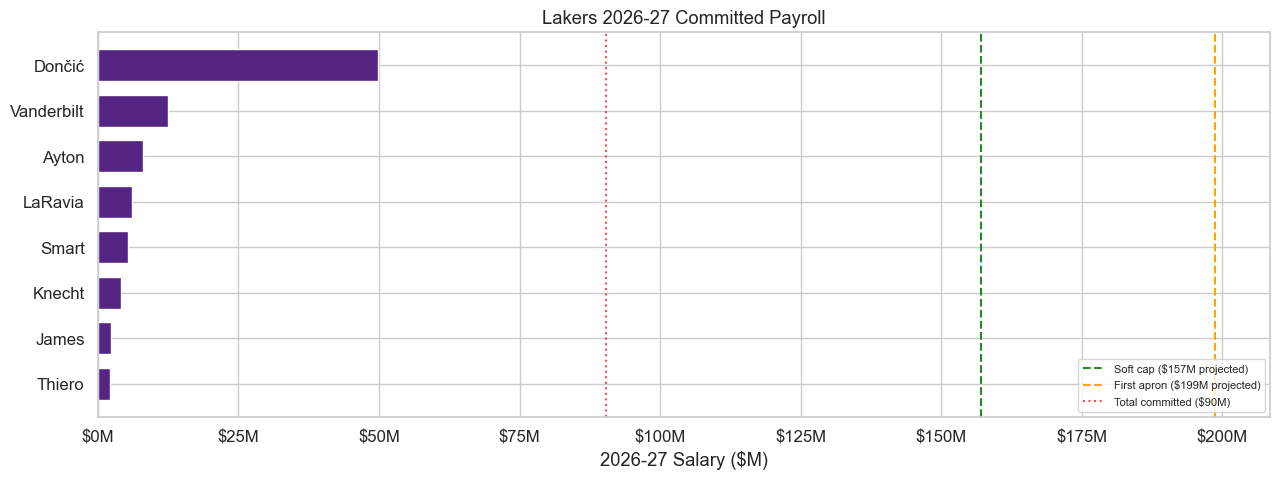

In [15]:
# Visual cap summary
fig, ax = plt.subplots(figsize=(13, 5))

players_with_salary = lakers[~lakers['IS_FREE_AGENT']].sort_values('2026-27', ascending=False)
names = players_with_salary['PLAYER_NAME'].str.split().str[-1].tolist()
salaries = (players_with_salary['2026-27'] / 1e6).tolist()

bar_colors = [LAKERS_GOLD if n in ['Doncic'] else LAKERS_PURPLE for n in names]
bars = ax.barh(names[::-1], salaries[::-1], color=bar_colors[::-1], height=0.7)

ax.axvline(SALARY_CAP_2026_27 / 1e6, color='forestgreen', linestyle='--', linewidth=1.5,
           label=f'Soft cap (${SALARY_CAP_2026_27/1e6:.0f}M projected)')
ax.axvline(FIRST_APRON_2026_27 / 1e6, color='orange', linestyle='--', linewidth=1.5,
           label=f'First apron (${FIRST_APRON_2026_27/1e6:.0f}M projected)')

total_bar_x = total_committed / 1e6
ax.axvline(total_bar_x, color='red', linestyle=':', linewidth=1.5, alpha=0.7,
           label=f'Total committed (${total_committed/1e6:.0f}M)')

ax.set_xlabel('2026-27 Salary ($M)')
ax.set_title('Lakers 2026-27 Committed Payroll')
ax.legend(loc='lower right', fontsize=8)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}M'))

plt.tight_layout()
plt.show()

**Reading the cap picture:**

The Lakers have significant committed payroll for 2026-27, led by Luka's supermax. The key question is how far they are from the second apron — teams above that threshold face severe trade restrictions (no salary aggregation, must trade down in total salary, lose access to most exceptions).

Several notable expiring contracts give the Lakers flexibility. LeBron, Rui Hachimura, Maxi Kleber, and Luke Kennard all come off the books. That's potentially significant cap relief — but also means roster holes that need filling.

**Bottom line:** The Lakers are likely a *trade team first* — they have committed salary to use as trade chips and will almost certainly operate above the luxury tax line regardless of offseason moves.

## E) Luka Complement Clustering Results

### The Methodology

Rather than hand-coding what a "Luka complement" looks like ("get a 3-and-D wing"), we cluster all qualifying players on style features and observe empirically which clusters the known successful Luka teammates land in.

**Style features used:**
- Usage rate (USG_PCT)
- Catch-and-shoot 3PT% and volume (CS_CATCH_SHOOT_FG3_PCT, CS_CATCH_SHOOT_FG3A)
- Defensive matchup plus/minus (PCT_PLUSMINUS)
- Three-point attempt rate (three_PAr)
- Assist, steal, block, and turnover percentages
- Offensive and defensive rebounding rates

**Validation players** (successful 2023-24 Dallas teammates of Luka): PJ Washington, Daniel Gafford, Dorian Finney-Smith, Maxi Kleber, Derrick Jones Jr, Tim Hardaway Jr.

In [16]:
# Silhouette scores for k=5 through k=12 (justifies choice of k=8)
silhouette_scores = df.attrs.get('silhouette_scores', {})
if silhouette_scores:
    print('=== CLUSTER QUALITY: SILHOUETTE SCORES ===')
    print('(Higher = more distinct clusters. Range: [-1, 1]. >0.2 is reasonable for player archetypes)')
    for k, score in sorted(silhouette_scores.items()):
        marker = ' <-- chosen' if k == 8 else ('  <-- best' if score == max(silhouette_scores.values()) and k != 8 else '')
        print(f'  k={k:2d}: silhouette = {score:.4f}{marker}')
    print()

# Where did the validation players land?
from src.features.luka_complement import EXPANDED_VALIDATION

print('=== EXPANDED VALIDATION PLAYER CLUSTER ASSIGNMENTS ===')
rows = []
for name, info in EXPANDED_VALIDATION.items():
    pid = info['id']
    archetype = info['archetype']
    season = info['season']
    row = df[df['PLAYER_ID'] == pid]
    if len(row) == 0:
        rows.append({'Player': name, 'Archetype': archetype, 'Season': season,
                     'Status': 'Historical lookup', 'Cluster': '(predicted)', 'Distance': '-', 'Team': '-'})
    else:
        r = row.iloc[0]
        cluster = int(r['COMPLEMENT_CLUSTER']) if pd.notna(r['COMPLEMENT_CLUSTER']) else 'Excl (low MIN)'
        dist = f"{r['COMPLEMENT_DISTANCE']:.3f}" if pd.notna(r['COMPLEMENT_DISTANCE']) else 'N/A'
        rows.append({'Player': name, 'Archetype': archetype, 'Season': season,
                     'Status': 'In 2025-26 dataset', 'Team': r['TEAM_ABBREVIATION'],
                     'Cluster': cluster, 'Distance': dist})
pd.DataFrame(rows)


=== CLUSTER QUALITY: SILHOUETTE SCORES ===
(Higher = more distinct clusters. Range: [-1, 1]. >0.2 is reasonable for player archetypes)
  k= 5: silhouette = 0.1472
  k= 6: silhouette = 0.1540  <-- best
  k= 7: silhouette = 0.1263
  k= 8: silhouette = 0.1447 <-- chosen
  k= 9: silhouette = 0.1343
  k=10: silhouette = 0.1246
  k=11: silhouette = 0.1288
  k=12: silhouette = 0.1333

=== EXPANDED VALIDATION PLAYER CLUSTER ASSIGNMENTS ===


,Player,Archetype,Season,Status,Team,Cluster,Distance
0,Daniel Gafford,rim_runner,2023-24,In 2025-26 dataset,DAL,6,5.523
1,Dereck Lively II,rim_runner,2023-24,In 2025-26 dataset,DAL,Excl (low MIN),N/A
2,Jaxson Hayes,rim_runner,2025-26,In 2025-26 dataset,LAL,5,6.853
3,PJ Washington,3d_wing,2023-24,In 2025-26 dataset,DAL,7,0.862
4,Dorian Finney-Smith,3d_wing,2022-23,In 2025-26 dataset,HOU,0,3.602
5,Derrick Jones Jr,3d_wing,2023-24,Historical lookup,-,(predicted),-
6,Kyrie Irving,secondary_creator,2023-24,Historical lookup,-,(predicted),-
7,Jalen Brunson,secondary_creator,2021-22,In 2025-26 dataset,NYK,2,2.019
8,Spencer Dinwiddie,secondary_creator,2021-22,Historical lookup,-,(predicted),-
9,Tim Hardaway Jr,shooter,2022-23,Historical lookup,-,(predicted),-


In [17]:
# Cluster profiles -- what defines each cluster?
print('=== CLUSTER PROFILES (mean z-scores per feature) ===')
print('Positive = above average, Negative = below average')
print()
profiles = cluster_profile(df)
# Highlight Luka complement clusters
luka_clusters = df[df['IS_LUKA_COMPLEMENT_CLUSTER']]['COMPLEMENT_CLUSTER'].dropna().unique()
print(f'Luka complement clusters: {sorted([int(c) for c in luka_clusters])}')
print()
profiles

=== CLUSTER PROFILES (mean z-scores per feature) ===
Positive = above average, Negative = below average

Luka complement clusters: [2, 7]



,USG_PCT,CS_CATCH_SHOOT_FG3_PCT,CS_CATCH_SHOOT_FG3A,PCT_PLUSMINUS,three_PAr,AST_PCT,STL%,BLK%,TOV%,OREB_PCT,DREB_PCT
cluster,,,,,,,,,,,
0.000,-0.280,0.270,0.780,0.250,0.890,-0.480,-0.370,-0.550,-0.730,-0.580,-0.640
1.000,0.480,-0.130,-0.670,-0.980,-1.080,-0.090,-0.340,1.720,0.090,1.420,1.760
2.000,1.410,0.150,-0.190,0.270,-0.360,1.440,0.080,-0.460,0.290,-0.550,-0.120
3.000,-0.270,-0.140,-0.480,0.840,0.100,0.470,0.110,-0.500,0.860,-0.430,-0.450
4.000,-0.850,-0.300,-0.380,-0.380,0.270,-0.490,1.510,0.010,0.020,0.130,-0.380
5.000,-1.060,6.600,-2.050,-0.160,-2.080,-0.970,-0.260,1.280,-0.280,2.110,1.010
6.000,-0.810,-2.380,-1.960,-0.880,-2.030,-0.570,-0.100,1.390,0.720,2.140,1.120
7.000,0.170,0.120,0.650,-0.460,0.130,-0.450,-0.470,0.460,-0.410,0.170,0.600


In [18]:
# Label each cluster based on its feature profile
CLUSTER_LABELS = {
    # These will be updated after inspecting the profiles above
    # Examples: 'Low-USG shooters', 'Rim protectors', 'Ball handlers', etc.
}

# Show player counts per cluster
cluster_counts = df[df['COMPLEMENT_CLUSTER'].notna()]['COMPLEMENT_CLUSTER'].value_counts().sort_index()
print('Players per cluster:')
for cluster_id, count in cluster_counts.items():
    is_complement = int(cluster_id) in [int(c) for c in luka_clusters]
    marker = ' <-- LUKA COMPLEMENT CLUSTER' if is_complement else ''
    print(f'  Cluster {int(cluster_id)}: {count} players{marker}')

Players per cluster:
  Cluster 0: 87 players
  Cluster 1: 21 players
  Cluster 2: 55 players <-- LUKA COMPLEMENT CLUSTER
  Cluster 3: 59 players
  Cluster 4: 39 players
  Cluster 5: 3 players
  Cluster 6: 26 players
  Cluster 7: 58 players <-- LUKA COMPLEMENT CLUSTER


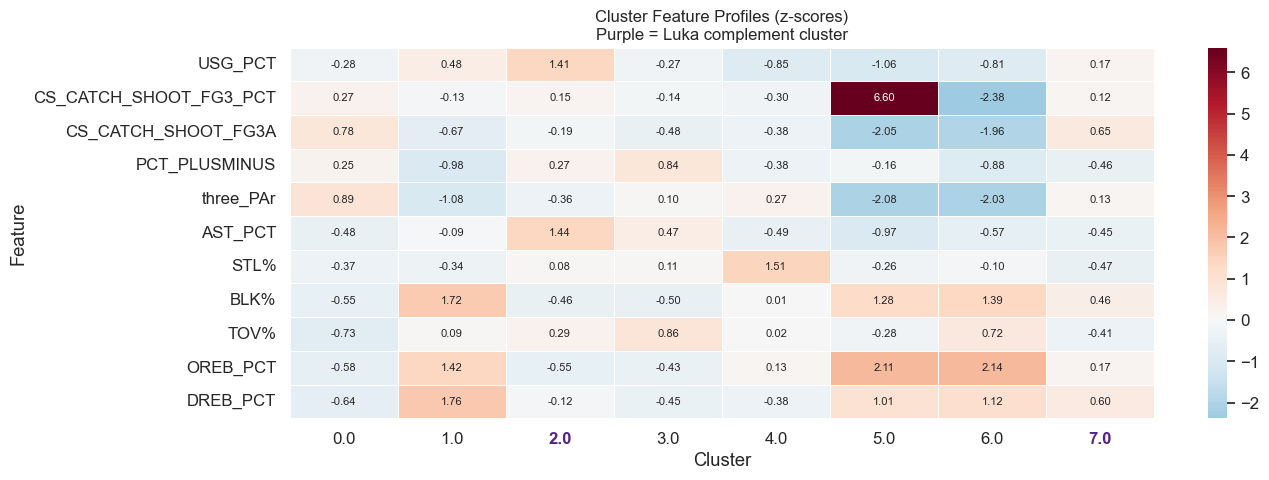

In [19]:
# Heatmap of cluster profiles
if not profiles.empty:
    fig, ax = plt.subplots(figsize=(14, 5))
    highlight_clusters = [c for c in profiles.index if int(c) in [int(x) for x in luka_clusters]]
    sns.heatmap(
        profiles.T,
        center=0, cmap='RdBu_r',
        annot=True, fmt='.2f', annot_kws={'size': 8},
        linewidths=0.5, ax=ax
    )
    # Mark Luka complement cluster columns
    for i, col in enumerate(profiles.index):
        if col in highlight_clusters:
            ax.get_xticklabels()[i].set_color(LAKERS_PURPLE)
            ax.get_xticklabels()[i].set_fontweight('bold')
    ax.set_title('Cluster Feature Profiles (z-scores)\nPurple = Luka complement cluster', fontsize=12)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.show()

In [20]:
# Top 20 non-Laker players by complement fit (closest to Luka complement centroid)
print('=== TOP 20 NON-LAKER LUKA COMPLEMENT TARGETS ===')
print('Ranked by COMPLEMENT_DISTANCE (lower = closer to the known Luka complement archetype)')
print()

complement_cols = [
    'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE',
    'COMPLEMENT_CLUSTER', 'COMPLEMENT_DISTANCE',
    'ON_COURT_VALUE', 'SURPLUS_VALUE', 'IS_FREE_AGENT'
]
avail_comp = [c for c in complement_cols if c in df.columns]
mask = (
    df['COMPLEMENT_DISTANCE'].notna() &
    (df['TEAM_ABBREVIATION'] != 'LAL') &
    df['ON_COURT_VALUE'].notna()
)
top_complements = df[mask].nsmallest(20, 'COMPLEMENT_DISTANCE')[avail_comp]
top_complements

=== TOP 20 NON-LAKER LUKA COMPLEMENT TARGETS ===
Ranked by COMPLEMENT_DISTANCE (lower = closer to the known Luka complement archetype)



,PLAYER_NAME,TEAM_ABBREVIATION,AGE,COMPLEMENT_CLUSTER,COMPLEMENT_DISTANCE,ON_COURT_VALUE,SURPLUS_VALUE,IS_FREE_AGENT
494,Santi Aldama,MEM,25.000,7.000,0.840,0.098,0.026,False
451,P.J. Washington,DAL,27.000,7.000,0.862,-0.755,-0.677,False
130,De'Aaron Fox,SAS,28.000,2.000,1.052,0.772,-1.873,False
84,Cedric Coward,MEM,22.000,7.000,1.111,-0.034,0.719,False
493,Sandro Mamukelashvili,TOR,27.000,7.000,1.125,1.010,1.562,False
470,Quinten Post,GSW,26.000,7.000,1.238,-0.158,NaN,True
446,Onyeka Okongwu,ATL,25.000,7.000,1.270,0.328,0.224,False
421,Naz Reid,MIN,26.000,7.000,1.342,0.193,-0.358,False
310,Julius Randle,MIN,31.000,2.000,1.344,0.496,-0.883,False
280,John Collins,LAC,28.000,7.000,1.357,0.238,NaN,True


## F) Roll Gravity, Rim Protection, and Big-Man Fit Scores

**Roll Gravity** captures lob threat / rim presence value: restricted-area finishing (NORMAL_FG_PCT),
offensive rebounding (OREB_PCT), and low usage (doesn't compete with Luka for creation reps).
BLK% was removed from this score -- rim protection is a *separate* dimension.

**Rim Protection** captures defensive anchor value: shot-blocking rate (BLK%) and defensive
rebounding (DREB_PCT). Some bigs (e.g. Lively) excel as lob threats but are still developing
defensively; others (Williams III) excel at both.

**Big-Man Fit Score** = Roll Gravity + Rim Protection. Identifies the bigs who fill both
Luka-specific needs simultaneously.


In [21]:
# Roll Gravity, Rim Protection, and Big-Man Fit leaderboards
score_cols = [
    'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE',
    'ROLL_GRAVITY_SCORE', 'ROLL_GRAVITY_RANK',
    'RIM_PROTECTION_SCORE', 'RIM_PROTECTION_RANK',
    'BIG_MAN_FIT_SCORE', 'BIG_MAN_FIT_RANK',
    'ON_COURT_VALUE', 'SURPLUS_VALUE',
]
available_cols = [c for c in score_cols if c in df.columns]

print('=== TOP 25 ROLL GRAVITY (lob threat / finishing) ===')
has_rg = df['ROLL_GRAVITY_SCORE'].notna()
print(df[has_rg][available_cols].nsmallest(25, 'ROLL_GRAVITY_RANK').to_string(index=False))

print('\n=== TOP 25 RIM PROTECTION (defensive anchor) ===')
has_rp = df['RIM_PROTECTION_SCORE'].notna() if 'RIM_PROTECTION_SCORE' in df.columns else pd.Series(False, index=df.index)
if has_rp.any():
    rp_cols = [c for c in available_cols if c != 'ROLL_GRAVITY_RANK']
    print(df[has_rp][rp_cols].nsmallest(25, 'RIM_PROTECTION_RANK').to_string(index=False))

print('\n=== TOP 25 BIG-MAN FIT (roll gravity + rim protection combined) ===')
has_bmf = df['BIG_MAN_FIT_SCORE'].notna() if 'BIG_MAN_FIT_SCORE' in df.columns else pd.Series(False, index=df.index)
if has_bmf.any():
    bmf_cols = [c for c in available_cols]
    print(df[has_bmf][bmf_cols].nsmallest(25, 'BIG_MAN_FIT_RANK').to_string(index=False))


=== TOP 25 ROLL GRAVITY (lob threat / finishing) ===
        PLAYER_NAME TEAM_ABBREVIATION    AGE  ROLL_GRAVITY_SCORE  ROLL_GRAVITY_RANK  RIM_PROTECTION_SCORE  RIM_PROTECTION_RANK  BIG_MAN_FIT_SCORE  BIG_MAN_FIT_RANK  ON_COURT_VALUE  SURPLUS_VALUE
       Steven Adams               HOU 32.000               7.943              1.000                 1.223               74.000              9.166             7.000           0.365          0.465
  Mitchell Robinson               NYK 28.000               7.850              2.000                 4.927                5.000             12.777             1.000           1.556            NaN
     Dylan Cardwell               SAC 24.000               6.679              3.000                 4.878                6.000             11.557             2.000          -0.157            NaN
     Andre Drummond               PHI 32.000               6.295              4.000                 4.084               11.000             10.379             5.000    

In [22]:
# Validation check: did Gafford, DJJ, Lively show up?
validation_roll_gravity = {
    'Daniel Gafford': 1629655,
    'Derrick Jones Jr': 1628407,
}
# Jalen Duren as additional proxy (elite rim runner)
extra_check = {'Jalen Duren': 1631096}

print('=== ROLL GRAVITY VALIDATION CHECK ===')
for name, pid in {**validation_roll_gravity, **extra_check}.items():
    row = df[df['PLAYER_ID'] == pid]
    if len(row) == 0:
        print(f'{name}: NOT in 2025-26 dataset')
    else:
        r = row.iloc[0]
        rg = r['ROLL_GRAVITY_SCORE']
        rank = r['ROLL_GRAVITY_RANK']
        status = 'PASS' if pd.notna(rg) and rg > 0 else 'FAIL'
        print(f'{name}: score={rg:.2f}, rank={rank:.0f} [{status}]')

=== ROLL GRAVITY VALIDATION CHECK ===
Daniel Gafford: score=4.76, rank=18 [PASS]
Derrick Jones Jr: NOT in 2025-26 dataset
Jalen Duren: score=1.46, rank=75 [PASS]


In [23]:
# High roll gravity AND undervalued (the best trade targets for rim depth)
print('=== HIGH ROLL GRAVITY + UNDERVALUED (non-Laker) ===')
rg_surplus = df[
    df['ROLL_GRAVITY_SCORE'].notna() &
    (df['ROLL_GRAVITY_SCORE'] > 1.5) &
    (
        (df['SURPLUS_VALUE'].notna() & (df['SURPLUS_VALUE'] > 0)) |
        (df['IS_FREE_AGENT'] & df['FA_VALUE'].notna() & (df['FA_VALUE'] > -0.5))
    ) &
    (df['TEAM_ABBREVIATION'] != 'LAL')
]
rg_surplus_cols = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE', 'ROLL_GRAVITY_SCORE',
                   'ON_COURT_VALUE', 'SURPLUS_VALUE', 'FA_VALUE', 'IS_FREE_AGENT']
avail_rgs = [c for c in rg_surplus_cols if c in rg_surplus.columns]
rg_surplus.sort_values('ROLL_GRAVITY_SCORE', ascending=False)[avail_rgs]

=== HIGH ROLL GRAVITY + UNDERVALUED (non-Laker) ===


,PLAYER_NAME,TEAM_ABBREVIATION,AGE,ROLL_GRAVITY_SCORE,ON_COURT_VALUE,SURPLUS_VALUE,FA_VALUE,IS_FREE_AGENT
511,Steven Adams,HOU,32.000,7.943,0.365,0.465,NaN,False
405,Mitchell Robinson,NYK,28.000,7.850,1.556,NaN,1.556,True
167,Dylan Cardwell,SAC,24.000,6.679,-0.157,NaN,-0.157,True
24,Andre Drummond,PHI,32.000,6.295,-0.192,NaN,-0.192,True
153,Donovan Clingan,POR,22.000,5.953,0.815,1.116,NaN,False
375,Luke Kornet,SAS,30.000,5.865,1.462,1.294,NaN,False
414,Moussa Diabaté,CHA,24.000,5.708,1.190,1.692,NaN,False
487,Ryan Kalkbrenner,CHA,24.000,5.412,1.276,1.747,NaN,False
323,Kel'el Ware,MIA,22.000,5.201,0.642,1.214,NaN,False
208,Isaiah Hartenstein,OKC,28.000,5.120,1.699,0.170,NaN,False


## G) Combined Target List: Who Should the Lakers Target?

Now we combine everything. The combined score takes:
- **Surplus value** (or FA value for free agents) — the efficiency signal
- **Complement fit** (inverse of distance to Luka complement centroid) — the style signal

Both are normalized to z-scores and averaged. High score = undervalued AND stylistically ideal for Luka's game.

This is the ranked list of players the Lakers should be targeting through trades and free agency.

In [24]:
# Top 30 combined targets (non-Lakers)
combined_cols = [
    'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE',
    'COMBINED_TARGET_SCORE', 'COMBINED_TARGET_RANK',
    'ON_COURT_VALUE', 'SURPLUS_VALUE', 'FA_VALUE',
    'COMPLEMENT_DISTANCE', 'ROLL_GRAVITY_SCORE',
    'IS_FREE_AGENT', 'SALARY_FORWARD'
]
avail_cb = [c for c in combined_cols if c in df.columns]

non_laker_mask = (
    (df['TEAM_ABBREVIATION'] != 'LAL') &
    df['COMBINED_TARGET_RANK'].notna()
)

targets = df[non_laker_mask].nsmallest(30, 'COMBINED_TARGET_RANK')[avail_cb].copy()

# Format salary
if 'SALARY_FORWARD' in targets.columns:
    targets['SALARY_FORWARD'] = targets['SALARY_FORWARD'].apply(
        lambda x: f'${x/1e6:.1f}M' if pd.notna(x) else 'FA'
    )

print('=== TOP 30 COMBINED LAKERS TARGETS (2026-27) ===')
targets

=== TOP 30 COMBINED LAKERS TARGETS (2026-27) ===


,PLAYER_NAME,TEAM_ABBREVIATION,AGE,COMBINED_TARGET_SCORE,COMBINED_TARGET_RANK,ON_COURT_VALUE,SURPLUS_VALUE,FA_VALUE,COMPLEMENT_DISTANCE,ROLL_GRAVITY_SCORE,IS_FREE_AGENT,SALARY_FORWARD
373,Luka Garza,BOS,27.000,1.864,1.000,1.344,1.760,NaN,3.141,4.005,False,$2.8M
493,Sandro Mamukelashvili,TOR,27.000,1.654,2.000,1.010,1.562,NaN,1.125,0.702,False,$2.8M
263,Jaylin Williams,OKC,23.000,1.484,3.000,1.018,1.218,NaN,3.105,1.691,False,$7.8M
264,Jaylon Tyson,CLE,23.000,1.328,4.000,0.315,1.089,NaN,1.497,-0.221,False,$3.7M
366,Leonard Miller,CHI,22.000,1.327,5.000,0.018,1.001,NaN,1.836,0.739,False,$2.4M
398,Micah Potter,IND,28.000,1.268,6.000,0.393,1.196,NaN,2.343,2.025,False,$2.8M
510,Stephon Castle,SAS,21.000,1.168,7.000,0.715,0.881,NaN,2.085,-0.934,False,$10.0M
232,Jalen Duren,DET,22.000,1.070,8.000,2.022,NaN,2.022,5.611,3.816,True,FA
487,Ryan Kalkbrenner,CHA,24.000,1.064,9.000,1.276,1.747,NaN,6.109,5.412,False,$2.4M
120,Daniss Jenkins,DET,24.000,1.046,10.000,-0.036,0.858,NaN,1.985,-1.408,False,$4.0M


In [25]:
# Split view: top trade targets (under contract) vs top FA targets
under_contract = df[
    ~df['IS_FREE_AGENT'] &
    (df['TEAM_ABBREVIATION'] != 'LAL') &
    df['SURPLUS_VALUE'].notna() &
    df['COMPLEMENT_DISTANCE'].notna()
].copy()

fa_targets = df[
    df['IS_FREE_AGENT'] &
    (df['TEAM_ABBREVIATION'] != 'LAL') &
    df['FA_VALUE'].notna() &
    df['COMPLEMENT_DISTANCE'].notna()
].copy()

trade_cols = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE', 'SURPLUS_VALUE', 'COMPLEMENT_DISTANCE', 'ROLL_GRAVITY_SCORE']
fa_cols_view = ['PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE', 'FA_VALUE', 'COMPLEMENT_DISTANCE', 'ROLL_GRAVITY_SCORE']

print('=== TOP 15 TRADE TARGETS (players under contract) ===')
avail_t = [c for c in trade_cols if c in under_contract.columns]
under_contract.nsmallest(15, 'COMPLEMENT_DISTANCE')[avail_t]

=== TOP 15 TRADE TARGETS (players under contract) ===


,PLAYER_NAME,TEAM_ABBREVIATION,AGE,SURPLUS_VALUE,COMPLEMENT_DISTANCE,ROLL_GRAVITY_SCORE
494,Santi Aldama,MEM,25.000,0.026,0.840,1.348
451,P.J. Washington,DAL,27.000,-0.677,0.862,0.813
130,De'Aaron Fox,SAS,28.000,-1.873,1.052,-2.683
84,Cedric Coward,MEM,22.000,0.719,1.111,-0.352
493,Sandro Mamukelashvili,TOR,27.000,1.562,1.125,0.702
446,Onyeka Okongwu,ATL,25.000,0.224,1.270,2.192
421,Naz Reid,MIN,26.000,-0.358,1.342,-0.149
310,Julius Randle,MIN,31.000,-0.883,1.344,-0.140
27,Andrew Wiggins,MIA,31.000,-0.824,1.447,0.189
140,Dennis Schröder,CLE,32.000,-0.376,1.464,-1.788


In [26]:
print('=== TOP 15 FREE AGENT TARGETS (no 2026-27 contract) ===')
print('These players can potentially be signed without trading assets.')
avail_fa_v = [c for c in fa_cols_view if c in fa_targets.columns]
fa_targets.nlargest(15, 'FA_VALUE')[avail_fa_v]

=== TOP 15 FREE AGENT TARGETS (no 2026-27 contract) ===
These players can potentially be signed without trading assets.


,PLAYER_NAME,TEAM_ABBREVIATION,AGE,FA_VALUE,COMPLEMENT_DISTANCE,ROLL_GRAVITY_SCORE
232,Jalen Duren,DET,22.000,2.022,5.611,3.816
478,Robert Williams III,POR,28.000,1.617,6.048,5.031
405,Mitchell Robinson,NYK,28.000,1.556,7.693,7.850
391,Matisse Thybulle,POR,29.000,1.045,8.094,-0.137
386,Mark Williams,PHX,24.000,0.975,7.108,5.036
257,Javonte Green,DET,32.000,0.850,3.824,0.869
525,Tobias Harris,DET,33.000,0.689,1.776,0.067
52,Bones Hyland,MIN,25.000,0.586,2.329,-2.113
104,Collin Gillespie,PHX,26.000,0.549,2.753,-0.557
184,Gary Payton II,GSW,33.000,0.547,3.272,1.857


In [27]:
# Summary visualization: top targets bubble chart -- Plotly for interactive tooltips
# Note: interactive in Jupyter, static in GitHub preview.

plot_targets = df[
    (df['TEAM_ABBREVIATION'] != 'LAL') &
    df['ON_COURT_VALUE'].notna() &
    df['COMPLEMENT_DISTANCE'].notna()
].copy()

# Use age-adjusted surplus for non-FAs, FA_VALUE for FAs
val_col = 'AGE_ADJUSTED_SURPLUS' if 'AGE_ADJUSTED_SURPLUS' in plot_targets.columns else 'SURPLUS_VALUE'
plot_targets['_value'] = plot_targets[val_col].fillna(plot_targets.get('FA_VALUE', pd.Series(dtype=float)))
plot_targets = plot_targets[plot_targets['_value'].notna()].copy()

fig = px.scatter(
    plot_targets,
    x='COMPLEMENT_DISTANCE',
    y='_value',
    color='BIG_MAN_FIT_SCORE' if 'BIG_MAN_FIT_SCORE' in plot_targets.columns else 'ROLL_GRAVITY_SCORE',
    color_continuous_scale='YlOrRd',
    hover_name='PLAYER_NAME',
    hover_data={
        'TEAM_ABBREVIATION': True,
        'AGE': True,
        'IS_FREE_AGENT': True,
        'COMPLEMENT_DISTANCE': ':.3f',
        '_value': ':.3f',
        'DURABILITY_SCORE': ':.3f',
    },
    title='Lakers Target Universe: Complement Fit vs. Age-Adjusted Value<br>'
          '<sup>Color = Big-Man Fit Score | Complement distance is a FILTER (vertical dashed line)</sup>',
    labels={
        'COMPLEMENT_DISTANCE': 'Complement Distance (lower = closer to Luka archetype)',
        '_value': f'{val_col} (positive = undervalued)',
        'BIG_MAN_FIT_SCORE': 'Big-Man Fit',
        'ROLL_GRAVITY_SCORE': 'Roll Gravity',
    },
    opacity=0.7,
)

# Complement filter threshold line
from src.features.luka_complement import COMPLEMENT_DISTANCE_THRESHOLD
fig.add_vline(x=COMPLEMENT_DISTANCE_THRESHOLD, line_dash='dot', line_color='gray',
              annotation_text='Complement filter threshold', annotation_position='top right')
fig.add_hline(y=0, line_dash='dash', line_color='gray', line_width=0.8)
fig.update_layout(width=950, height=680)
fig.show()

# Save interactive HTML
import os
os.makedirs('../docs', exist_ok=True)
fig.write_html('../docs/target_universe_interactive.html')
print('Interactive chart saved to docs/target_universe_interactive.html')

# --- Matplotlib fallback ---
# fig2, ax = plt.subplots(figsize=(12,8))
# sc = ax.scatter(plot_targets['COMPLEMENT_DISTANCE'], plot_targets['_value'],
#                 c=plot_targets['ROLL_GRAVITY_SCORE'], cmap='YlOrRd', s=30, alpha=0.6)
# plt.colorbar(sc, ax=ax, label='Roll Gravity Score')
# plt.tight_layout(); plt.show()


Interactive chart saved to docs/target_universe_interactive.html


## H) Methodology Notes and Limitations

### Weights and Thresholds (Phase 1.5)

Every weight, threshold, and modeling choice is a starting hypothesis. Constants are defined at the
top of their respective modules for transparency.

| Parameter | Value | Location | Rationale |
|-----------|-------|----------|-----------|
| BPM weight | 35% | `player_value.py::ON_COURT_WEIGHTS` | Best individual-impact metric, independent of team context |
| VORP weight | 0% (removed) | `player_value.py::ON_COURT_WEIGHTS` | Derived from BPM x minutes -- double-counts BPM |
| WS/48 weight | 20% | `player_value.py::ON_COURT_WEIGHTS` | Different methodology from BPM; genuine additional signal |
| NET_RATING weight | 25% | `player_value.py::ON_COURT_WEIGHTS` | Team-level on/off impact; captures defensive contributions BPM misses |
| TS% weight | 20% | `player_value.py::ON_COURT_WEIGHTS` | Pure scoring efficiency; independent axis |
| Min GP | 20 | `player_value.py::MIN_GP` | Small-sample exclusion |
| Min MIN/game | 15 | `player_value.py::MIN_MIN` | Garbage-time exclusion |
| Z-score population | Qualifying only | `player_value.py` | Mean/std from rotation players (GP>=20, MIN>=15); 0 = average rotation player |
| Surplus methodology | Regression-based | `player_value.py` | OLS: salary ~ ON_COURT_VALUE; surplus = expected - actual salary |
| Age factor | Step function | `player_value.py::age_factor()` | Peak 25-28; penalty after 28; bonus before 25 |
| K-means clusters | 8 | `luka_complement.py::KMEANS_K` | See silhouette scores above for justification |
| Complement threshold | 2 | `luka_complement.py::COMPLEMENT_CLUSTER_MIN` | Cluster must contain 2+ validation players from same archetype |
| Complement filter | Distance < 2.0 | `luka_complement.py::COMPLEMENT_DISTANCE_THRESHOLD` | Filter gate; players outside get 0.5x discount |
| Forward salary cap | $157M | `constants.py::SALARY_CAP_2026_27` | ~2% projected growth from 2025-26 |
| YEARS_REMAINING | 2026-27 onward only | `salaries.py` | 2025-26 season is over for trade analysis purposes |
| Austin Reaves | IS_FREE_AGENT=True | `constants.py::PLAYER_OPTION_OVERRIDES` | PO decline hardcoded; he will seek max extension |

### Known Limitations

**1. System effects are real and unresolved.**  
All of BPM, WS, VORP, and NET_RATING measure outcomes in a player's actual team context. A player
on a great team with great spacing looks better than an equivalent player on a bad team. This is an
inherent limitation of public metrics.

**2. Defensive metrics are thin.**  
The only direct defensive signal from nba_api is the close-defense FG% differential (`PCT_PLUSMINUS`).
We have no opponent scoring by matchup, no contested shot rates beyond that. Defensive BPM from BBRef
is the best available proxy. Elite defenders may be underrated by this model.

**3. No restricted-area FG% for roll gravity.**  
We use `NORMAL_FG_PCT` (FG% on non-catch-and-shoot, non-pull-up shots) as a proxy for restricted-area
finishing. This is noisy -- it captures layups, posts, and cuts but also free-throw-drawing plays.
Zone-specific shooting data would be cleaner.

**4. Historical validation players use a feature subset.**  
Catch-and-shoot data and defensive matchup data are only cached for 2024-25 and 2025-26. Historical
validation players (Gafford 2023-24, Brunson 2021-22, etc.) are predicted from the nba_api advanced
stats only (USG_PCT, AST_PCT, OREB_PCT, DREB_PCT, NET_RATING, TS_PCT), with missing features imputed
at population mean. This slightly degrades cluster assignment accuracy for historical players.

**5. Salary data is 2025-26 season only.**  
We have one season of salary data. YEARS_REMAINING is computed from the BBRef CSV forward columns
(2026-27 onward). Player options are manually hardcoded in `constants.py::PLAYER_OPTION_OVERRIDES`
and `KNOWN_OPTIONS_2026_27`.

**6. Age curve is a step function, not empirically fitted.**  
The `age_factor()` step function encodes conventional NBA aging wisdom but is not derived from
historical aging data. Phase 2 will replace this with a fitted aging curve from career trajectories.

### Future Improvements

- **EPM (dunksandthrees.com, $50/year)** and **LEBRON (Basketball Reference / Cleaning the Glass)**
  are the two best publicly available all-in-one metrics for isolating individual impact from team
  effects. EPM or LEBRON would likely replace or heavily supplement BPM as the primary metric.
  RAPTOR (FiveThirtyEight) is not listed -- the project was discontinued in 2023.
- **Play-type data**: Roll-man FGA and FG% from PBP Stats or Second Spectrum would replace the
  NORMAL_FG_PCT proxy for roll gravity.
- **Cleaning the Glass filtered stats**: Garbage-time-excluded metrics would sharpen signal for
  players on bad teams.
- **Fitted aging curve**: Using historical career trajectories to model the performance-age
  relationship, replacing the current step function.
- **Lineup data**: Empirically measuring which player types produce best alongside ball-dominant
  creators would validate or replace the clustering approach.


In [28]:
# Save the fully valued dataset for downstream use
import os
output_path = '../data/cache/player_valued_2025-26.parquet'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df.to_parquet(output_path, index=False)
print(f'Saved valued dataset to {output_path}')
print(f'Shape: {df.shape}')
print('\nNew columns added in Phase 1:')
new_cols = [c for c in df.columns if c not in raw.columns]
print(new_cols)

Saved valued dataset to ../data/cache/player_valued_2025-26.parquet
Shape: (582, 221)

New columns added in Phase 1:
['Z_BPM', 'Z_VORP', 'Z_WS', 'Z_WS_48', 'Z_NET_RATING', 'Z_TS_PCT', 'ON_COURT_VALUE', 'SALARY_CURRENT', 'SALARY_FORWARD', 'IS_FREE_AGENT', 'CONTRACT_VALUE', 'SALARY_RANK_PCT', 'CONTRACT_VALUE_Z', 'EXPECTED_SALARY', 'SURPLUS_VALUE_DOLLARS', 'SURPLUS_VALUE', 'SURPLUS_RANK', 'AGE_FACTOR', 'AGE_ADJUSTED_SURPLUS', 'FA_VALUE', 'FA_VALUE_RANK', 'DURABILITY_SCORE', 'MAJOR_INJURY_FLAGS', 'ADJUSTED_VALUE', 'COMPLEMENT_CLUSTER', 'COMPLEMENT_DISTANCE', 'IS_LUKA_COMPLEMENT_CLUSTER', 'COMPLEMENT_FIT_RANK', 'ROLL_GRAVITY_SCORE', 'ROLL_GRAVITY_RANK', 'RIM_PROTECTION_SCORE', 'RIM_PROTECTION_RANK', 'BIG_MAN_FIT_SCORE', 'BIG_MAN_FIT_RANK', 'COMBINED_TARGET_SCORE', 'COMBINED_TARGET_RANK']
